In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from stock_predict.database.session import SessionLocal
from stock_predict.repositories.item_repository import ItemRepository
from stock_predict.repositories.movement_repository import MovementRepository
from stock_predict.services.aggregation import build_time_series
from stock_predict.schemas.config import Granularity

In [2]:
db = SessionLocal()
items = ItemRepository(db).list_all()

print(f"{len(items)} itens no banco\n")
for item in items[:10]:  # só os 10 primeiros, pra não poluir a tela
    print(f"[{item.id}] {item.external_id} - {item.description}")

3941 itens no banco

[1] 85123A - WHITE HANGING HEART T-LIGHT HOLDER
[2] 71053 - WHITE METAL LANTERN
[3] 84406B - CREAM CUPID HEARTS COAT HANGER
[4] 84029G - KNITTED UNION FLAG HOT WATER BOTTLE
[5] 84029E - RED WOOLLY HOTTIE WHITE HEART.
[6] 22752 - SET 7 BABUSHKA NESTING BOXES
[7] 21730 - GLASS STAR FROSTED T-LIGHT HOLDER
[8] 22633 - HAND WARMER UNION JACK
[9] 22632 - HAND WARMER RED POLKA DOT
[10] 84879 - ASSORTED COLOUR BIRD ORNAMENT


In [3]:
ITEM_ID_ESCOLHIDO = 1

movement_repo = MovementRepository(db)
movements = movement_repo.get_by_item(ITEM_ID_ESCOLHIDO)

series = build_time_series(movements, Granularity.WEEKLY)
print(series)

       period  demand
0  2010-12-05   986.0
1  2010-12-12  1045.0
2  2010-12-19  1524.0
3  2010-12-26   198.0
4  2011-01-02     0.0
5  2011-01-09   973.0
6  2011-01-16  3329.0
7  2011-01-23   661.0
8  2011-01-30   541.0
9  2011-02-06   586.0
10 2011-02-13   517.0
11 2011-02-20   365.0
12 2011-02-27   401.0
13 2011-03-06   380.0
14 2011-03-13   454.0
15 2011-03-20   465.0
16 2011-03-27   365.0
17 2011-04-03   582.0
18 2011-04-10   374.0
19 2011-04-17   474.0
20 2011-04-24  2422.0
21 2011-05-01   375.0
22 2011-05-08  1144.0
23 2011-05-15   873.0
24 2011-05-22   783.0
25 2011-05-29  1026.0
26 2011-06-05   628.0
27 2011-06-12  4389.0
28 2011-06-19   389.0
29 2011-06-26   236.0
30 2011-07-03   259.0
31 2011-07-10   258.0
32 2011-07-17  1195.0
33 2011-07-24   719.0
34 2011-07-31   780.0
35 2011-08-07   441.0
36 2011-08-14   466.0
37 2011-08-21   296.0
38 2011-08-28   773.0
39 2011-09-04   394.0
40 2011-09-11   440.0
41 2011-09-18   658.0
42 2011-09-25   705.0
43 2011-10-02   402.0
44 2011-10

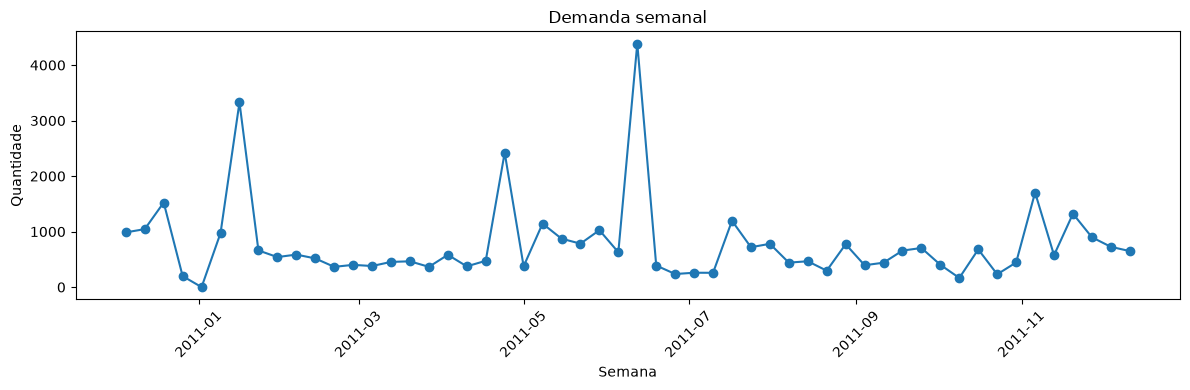

In [4]:
plt.figure(figsize=(12, 4))
plt.plot(series["period"], series["demand"], marker="o")
plt.title("Demanda semanal")
plt.xlabel("Semana")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
from stock_predict.ml.xgboost_model import XGBoostForecastModel
from stock_predict.services.evaluation import walk_forward_validation

In [6]:
model = XGBoostForecastModel(n_lags=4)

model.fit(series)

forecast = model.predict(horizon=7)

forecast

,period,predicted_quantity
0,2011-12-18,564.446411
1,2011-12-25,490.020905
2,2012-01-01,382.241760
3,2012-01-08,600.740845
4,2012-01-15,433.116760
5,2012-01-22,925.836243
6,2012-01-29,548.609985


In [7]:
results = walk_forward_validation(
    series=series,
    model_factory=lambda: XGBoostForecastModel(n_lags=4),
    horizon=7,
    min_train_size=5,
)

results

{'metrics': {'wape': 0.7651525309765913,
  'mae': 556.7107461426427,
  'rmse': 1002.3538000302456},
 'predictions':         period  actual    predicted
 0   2011-01-09   973.0     0.000000
 1   2011-01-16  3329.0     0.000000
 2   2011-01-23   661.0     0.000000
 3   2011-01-30   541.0     0.000000
 4   2011-02-06   586.0     0.000000
 ..         ...     ...          ...
 296 2011-11-13   575.0   288.992065
 297 2011-11-20  1322.0  1663.198120
 298 2011-11-27   898.0   510.987396
 299 2011-12-04   726.0   649.378418
 300 2011-12-11   649.0  1088.048584
 
 [301 rows x 3 columns]}

In [8]:
series["demand"].describe()

count      54.000000
mean      771.555556
std       748.004986
min         0.000000
25%       390.250000
50%       578.500000
75%       850.500000
max      4389.000000
Name: demand, dtype: float64

In [9]:
forecast = XGBoostForecastModel(n_lags=4)
forecast.fit(series)

predictions = forecast.predict(horizon=7)

predictions

,period,predicted_quantity
0,2011-12-18,564.446411
1,2011-12-25,490.020905
2,2012-01-01,382.241760
3,2012-01-08,600.740845
4,2012-01-15,433.116760
5,2012-01-22,925.836243
6,2012-01-29,548.609985


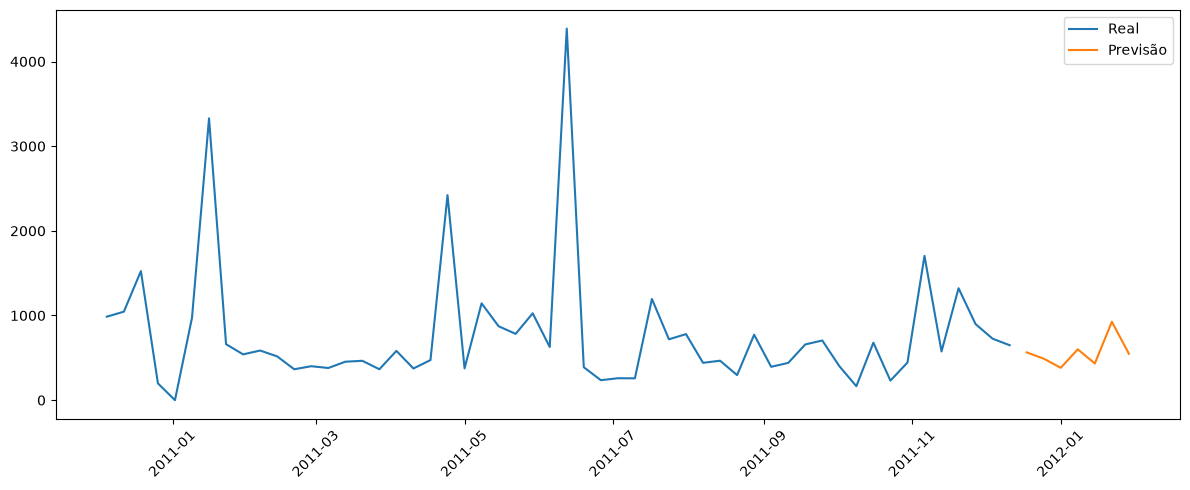

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(series["period"], series["demand"], label="Real")

plt.plot(
    predictions["period"],
    predictions["predicted_quantity"],
    label="Previsão",
)

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
from stock_predict.ml.baseline_model import BaselineForecastModel

model = BaselineForecastModel()

model.fit(series)

forecast = model.predict(horizon=7)

forecast

,period,predicted_quantity
0,2011-12-18,649.0
1,2011-12-25,649.0
2,2012-01-01,649.0
3,2012-01-08,649.0
4,2012-01-15,649.0
5,2012-01-22,649.0
6,2012-01-29,649.0


In [16]:
baseline_result = walk_forward_validation(
    series=series,
    model_factory=BaselineForecastModel,
    horizon=7,
    min_train_size=10,
)

In [17]:
xgboost_result = walk_forward_validation(
    series=series,
    model_factory=lambda: XGBoostForecastModel(n_lags=4),
    horizon=7,
    min_train_size=10,
)

In [18]:
baseline = baseline_result["metrics"]
xgb = xgboost_result["metrics"]

for metric in ["wape", "mae", "rmse"]:
    improvement = (baseline[metric] - xgb[metric]) / baseline[metric] * 100
    print(f"{metric}: {improvement:.2f}%")

wape: 9.74%
mae: 9.74%
rmse: 7.58%
